# S07 : From atom-to-atom mapping reactions to DPO rules

## Aim of this talktorial

Establish a chemically interpretable and mathematically pipeline for transforming mapped reactions into formal graph rewriting rules.

## Learning outcomes

After completing S07, you can:

1. Construct ensemble atom map using graph isomorphsim
2. Construct an <b>ITS graph</b> from a mapped reaction.
3. Extract a <b>reaction center</b>.
4. Cluster reaction centers using <b>graph isomorphism</b>.
5. Speed up clustering via <b>WL hashing</b> as an isomorphism-invariant *prefilter*.
6. Convert a reaction center into a <b>DPO rule</b> $L \leftarrow K \rightarrow R$.


## Outline

- [0. Setup & Data](#0-setup--data)
- [1. Standardize and canonicalize](#1-standardize-and-canonicalize)
- [2. Ensemblem atom-to-atom mapping](#2-ensemblem-atom-to-atom-mapping)
- [3. Rule library construction](#3-rule-library-construction)
- [4. Discussion](#4-discussion)
- [5. Quiz](#5-quiz)
- [6. References](#6-references)

### Pipeline overview: from mapped reactions to DPO rule library

The complete S07 workflow can be summarized as a linear pipeline.
Each step reduces ambiguity and increases reproducibility.

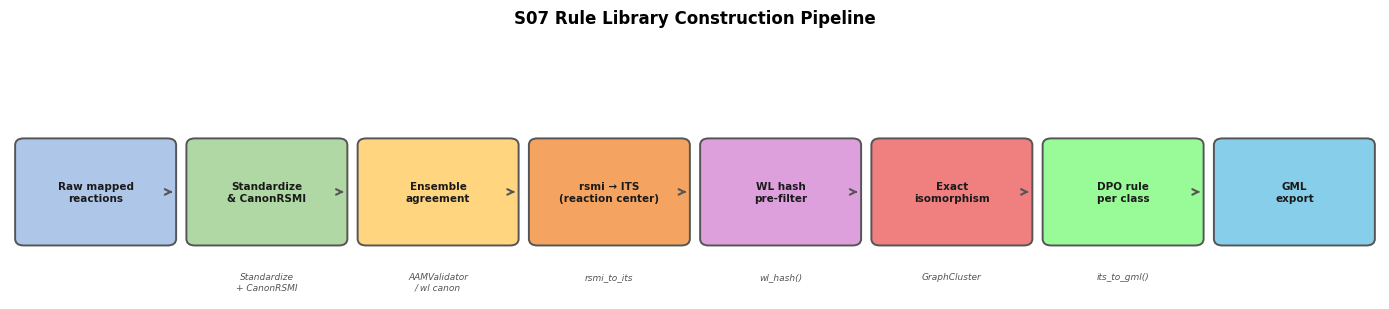

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_steps = [
    ('Raw mapped\nreactions', '#AEC6E8'),
    ('Standardize\n& CanonRSMI', '#B0D8A4'),
    ('Ensemble\nagreement', '#FFD580'),
    ('rsmi → ITS\n(reaction center)', '#F4A460'),
    ('WL hash\npre-filter', '#DDA0DD'),
    ('Exact\nisomorphism', '#F08080'),
    ('DPO rule\nper class', '#98FB98'),
    ('GML\nexport', '#87CEEB'),
]

fig, ax = plt.subplots(figsize=(14, 3.2), facecolor='white')
ax.set_xlim(-0.5, len(_steps) - 0.5)
ax.set_ylim(-0.8, 1.2)
ax.set_axis_off()
ax.set_title('S07 Rule Library Construction Pipeline', fontsize=12, fontweight='bold')

for i, (label, color) in enumerate(_steps):
    box = mpatches.FancyBboxPatch(
        (i - 0.42, -0.35),
        0.84,
        0.70,
        boxstyle='round,pad=0.05',
        fc=color,
        ec='#555555',
        lw=1.4,
        zorder=2,
    )
    ax.add_patch(box)
    ax.text(
        i,
        0.0,
        label,
        ha='center',
        va='center',
        fontsize=7.5,
        fontweight='bold',
        color='#1a1a1a',
        zorder=3,
    )
    if i < len(_steps) - 1:
        ax.annotate(
            '',
            xy=(i + 0.45, 0),
            xytext=(i + 0.42, 0),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5),
        )

_tools = [
    '',
    'Standardize\n+ CanonRSMI',
    'AAMValidator\n/ wl canon',
    'rsmi_to_its',
    'wl_hash()',
    'GraphCluster',
    'its_to_gml()',
    '',
]
for i, tool in enumerate(_tools):
    if tool:
        ax.text(
            i,
            -0.60,
            tool,
            ha='center',
            va='top',
            fontsize=6.5,
            color='#555',
            style='italic',
        )

plt.tight_layout()
plt.show()

## 0. Setup & data


This notebook uses **SynKit** [[1]](#ref-1). to accelerate development: fast access to molecular graphs, rule application (DPO/ITS), pattern matching, and utilities for building reaction-centric workflows.

we can easily install synkit via pypi:
```bash
pip install synkit
```

In [2]:
import rdkit
import pandas as pd
import networkx as nx
from pathlib import Path
import importlib.metadata as m
from synkit.IO import load_database

print("RDKit version:", rdkit.__version__)
print("NetworkX version:", nx.__version__)
print("SynKit version:", m.version('synkit'))

DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / "data_aam.json.gz"
data = pd.DataFrame(
    load_database(DATA_PATH)[:10000]
)  # we use 10000 data points for fast process
display(data.head())
print(data.shape)

RDKit version: 2025.09.3
NetworkX version: 3.6.1
SynKit version: 1.3.2


,R-id,reactions,rxn_mapper,graphormer,local_mapper,class,org_rxn
0,0,COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(...,[CH3:1][O:2][C:3](=[O:4])[C@H:5]([CH2:6][CH2:7...,[CH3:33][C:32]([CH3:34])([CH3:35])[c:31]1[c:36...,[CH3:1][O:2][C:3](=[O:4])[C@H:5]([CH2:6][CH2:7...,6,COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(...
1,1,Nc1cccc2cnccc12.O=C(O)c1cc([N+](=O)[O-])c(Sc2c...,[NH2:3][c:4]1[cH:5][cH:6][cH:7][c:8]2[cH:9][n:...,[Cl:25][c:24]1[cH:26][n:27][cH:28][c:29]([Cl:3...,[NH2:3][c:4]1[cH:5][cH:6][cH:7][c:8]2[cH:9][n:...,2,Nc1cccc2cnccc12.O=C(O)c1cc([N+](=O)[O-])c(Sc2c...
2,2,CCNCC.Cc1nc(-c2ccc(C=O)cc2)sc1COc1ccc([C@H](CC...,[CH3:1][CH2:2][NH:3][CH2:4][CH3:5].[CH3:14][c:...,[CH2:2]([CH3:1])[NH:3][CH2:4][CH3:5].[H:50][H:...,[CH3:1][CH2:2][NH:3][CH2:4][CH3:5].[CH3:14][c:...,1,CCNCC.Cc1nc(-c2ccc(C=O)cc2)sc1COc1ccc([C@H](CC...
3,3,CC1(C)CCC(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC...,[CH3:1][C:2]1([CH3:3])[CH2:4][CH2:5][C:6]([CH2...,[CH2:64]([F:65])[C:61]([CH2:62][F:63])=[O:60]....,[CH3:1][C:2]1([CH3:3])[CH2:4][CH2:5][C:6]([CH2...,1,CC1(C)CCC(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC...
4,4,CCOc1ccc(Oc2ncnc3c2cnn3C2CCNCC2)c(F)c1.O=C(Cl)...,[CH3:1][CH2:2][O:3][c:4]1[cH:5][cH:6][c:7]([O:...,[CH2:19]1[CH2:20][NH:21][CH2:22][CH2:23][CH:18...,[CH3:1][CH2:2][O:3][c:4]1[cH:5][cH:6][c:7]([O:...,2,CCOc1ccc(Oc2ncnc3c2cnn3C2CCNCC2)c(F)c1.O=C(Cl)...


(10000, 7)


The dataset incorporates three distinct atom mapping methodologies: `rxn_mapper` [[2]](#ref-2), `graphormer` mapper [[3]](#ref-3), and `local_mapper` [[4]](#ref-4).

## 1. Standardize and canonicalize

1. Validate & standardize SMILES using `Standardize` (drop invalid/unparsable).

2. Canonicalize atom-map numbers with `CanonRSMI` (from **S06**) for identical mappings.

In [3]:
from tqdm.auto import tqdm
from synkit.Chem.Reaction.standardize import Standardize
from synkit.Chem.Reaction.canon_rsmi import CanonRSMI

tqdm.pandas(desc="Canonicalizing")


def std_canon(aam: str):
    if aam is None:
        return None
    try:
        std = Standardize()
        canon = CanonRSMI(wl_iterations=4)
        aam_std = std.fit(aam, remove_aam=False)
        canon_out = canon.canonicalise(aam_std)
        return getattr(canon_out, "canonical_rsmi", None)
    except Exception:
        return None


tqdm.pandas(desc="Canonicalizing — rxn_mapper")
data['rxn_canon'] = data['rxn_mapper'].progress_apply(std_canon)

tqdm.pandas(desc="Canonicalizing — graphormer")
data['graph_canon'] = data['graphormer'].progress_apply(std_canon)

tqdm.pandas(desc="Canonicalizing — local_mapper")
data['local_canon'] = data['local_mapper'].progress_apply(std_canon)

/home/lolo/miniforge3/envs/synedu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Canonicalizing — local_mapper: 100%|██████████| 10000/10000 [00:48<00:00, 204.95it/s]


## 2. Ensemblem atom-to-atom mapping

Compare the canonicalized mapper outputs by exact string equality, rows where all canonical maps match are high-confidence aam assignments [[5]](#ref-5).

**Definition (Canonical Reaction SMILES).**  
Two atom-mapped reaction SMILES $s_1$ and $s_2$ are *equivalent* if their corresponding ITS graphs $\Gamma_1$ and $\Gamma_2$ are isomorphic as labeled graphs: $\Gamma_1 \cong \Gamma_2$. The *canonical reaction SMILES* $\mathrm{canon}(s)$ is the lexicographically smallest string in the equivalence class, obtained by applying a canonical atom-map permutation $\pi: \mathbb{N} \to \mathbb{N}$ computed via WL refinement (approximation) or IR (exact).

**Definition (Ensemble Agreement).**  
Given $n$ atom-mapping functions $\varphi_1, \ldots, \varphi_n$ applied to the same reaction $\varrho$, the ensemble *agrees* on $\varrho$ if all canonical strings are identical:

$$
\mathrm{canon}(\varphi_1(\varrho)) = \mathrm{canon}(\varphi_2(\varrho)) = \cdots = \mathrm{canon}(\varphi_n(\varrho))
$$

When the ensemble disagrees, *refinement* (exact isomorphism check) is used to resolve the discrepancy.

**Definition (WL Reaction Hash).**  
The *WL hash* of a reaction center ITS $\Gamma_{\mathrm{RC}}$ is the string representation of the stable WL partition histogram:

$$
h_{\mathrm{WL}}(\Gamma_{\mathrm{RC}}) = \mathrm{encode}\!\left(\mathcal{P}^*(\Gamma_{\mathrm{RC}})\right)
$$

Reactions with identical WL hashes are *candidate isomorphs*; exact isomorphism (graph matching) is then used to confirm.


In [4]:
import pandas as pd
from typing import Tuple, List, Union, Sequence


def extract_aam(
    df: pd.DataFrame,
    keys: Sequence[str] = ("rxn_mapper", "graphormer", "local_mapper"),
    strip: bool = True,
    require_not_none: bool = True,
    return_indices: bool = False,
    inplace: bool = False,
) -> Union[
    Tuple[pd.DataFrame, pd.DataFrame],
    Tuple[pd.DataFrame, List[int], pd.DataFrame, List[int]],
]:
    k0, k1, k2 = keys
    s0, s1, s2 = df[k0].copy(), df[k1].copy(), df[k2].copy()
    if strip:
        mask0 = s0.map(lambda x: isinstance(x, str))
        mask1 = s1.map(lambda x: isinstance(x, str))
        mask2 = s2.map(lambda x: isinstance(x, str))
        if mask0.any():
            s0.loc[mask0] = s0.loc[mask0].str.strip()
        if mask1.any():
            s1.loc[mask1] = s1.loc[mask1].str.strip()
        if mask2.any():
            s2.loc[mask2] = s2.loc[mask2].str.strip()
    if require_not_none:
        non_null = s0.notna() & s1.notna() & s2.notna()
    else:
        non_null = pd.Series(True, index=df.index)
    eq_mask = non_null & s0.eq(s1) & s1.eq(s2)
    out_df = df.loc[eq_mask].copy()
    non_out_df = df.loc[~eq_mask].copy()
    if not out_df.empty:
        out_df = out_df.assign(aam=s0.loc[eq_mask].values)
        out_df = out_df.drop(columns=[k0, k1, k2], errors="ignore")
    if inplace:
        df.drop(df.index, inplace=True)
        for col in out_df.columns:
            df[col] = out_df[col].values
        df.reset_index(drop=True, inplace=True)
    if return_indices:
        return out_df, out_df.index.to_list(), non_out_df, non_out_df.index.to_list()
    return out_df, non_out_df


out, rest = extract_aam(data, keys=("rxn_canon", "graph_canon", "local_canon"))
print("Equivalent maps:", len(out))
print("Non equivalent maps:", len(rest))

Equivalent maps: 8491
Non equivalent maps: 1509


 Weisfeiler-Lehman [[6]](#ref-6) based canonicalization is fast but not exact. Use WL to filter and only run an exact isomorphism check on mappings that WL says are different (or on any ambiguous cases).

In **SynKit**, we expose `AAMValidator` to compare directly atom-to-atom map by converting to ITS and checking isomorphism

In [5]:
import pandas as pd
from typing import Sequence, Tuple
from synkit.Chem.Reaction.aam_validator import AAMValidator

import pandas as pd
from typing import Sequence, Tuple, Optional
from synkit.Chem.Reaction.aam_validator import AAMValidator


def refinement(
    df: pd.DataFrame,
    aam_cols: Sequence[str] = ("rxn_canon", "graph_canon", "local_canon"),
    validator: Optional[AAMValidator] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if validator is None:
        validator = AAMValidator()
    cols = list(aam_cols)
    if len(cols) < 2:
        raise ValueError("aam_cols must contain at least two columns")
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"missing columns: {missing}")
    df2 = df.copy()
    df2[cols] = df2[cols].applymap(lambda x: x.strip() if isinstance(x, str) else x)
    ref = cols[0]
    solved_idx, unsolved_idx = [], []
    for idx, row in df2[cols].iterrows():
        ref_val = row[ref]
        if ref_val is None or pd.isna(ref_val):
            unsolved_idx.append(idx)
            continue
        ok = True
        for c in cols[1:]:
            val = row[c]
            if val is None or pd.isna(val):
                ok = False
                break
            try:
                if not bool(validator.smiles_check(ref_val, val)):
                    ok = False
                    break
            except Exception:
                ok = False
                break
        (solved_idx if ok else unsolved_idx).append(idx)
    solved = df2.loc[solved_idx].copy()
    solved = solved.drop(columns=[c for c in cols if c != ref], errors="ignore")
    solved = solved.rename(columns={ref: "aam"})
    unsolved = df2.loc[unsolved_idx].copy()
    return solved, unsolved


solve, unsolve = refinement(rest)

/tmp/ipykernel_3562105/4258269968.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df2[cols] = df2[cols].applymap(lambda x: x.strip() if isinstance(x, str) else x)
2026-05-20 16:29:10,780 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:14,661 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:15,071 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:15,124 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:15,573 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:15,942 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:16,815 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:16,896 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:19,216 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:19,351 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:20,128 - WARNING - Failed to parse SMILES: None
2026-05-20 16:29:20,361 - WARNING - Failed to parse SMILES: None
2026-05-20 16:

In [6]:
df_aam = pd.concat([out, solve], axis=0)
df_aam.shape

(8975, 8)

### Ensemble mapper agreement distribution

Three mappers (RXNMapper, Graphormer, Local Mapper) each produce an atom map for each reaction. The ensemble step classifies reactions by how many mappers agree. High-confidence reactions (all three agree) form the primary training signal; disagreements are resolved by WL-based isomorphism checking or discarded.

2026-05-20 16:29:23,725 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-20 16:29:23,726 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


df_aam shape: (8975, 8)
Columns: ['R-id', 'reactions', 'rxn_mapper', 'graphormer', 'local_mapper', 'class', 'org_rxn', 'aam']


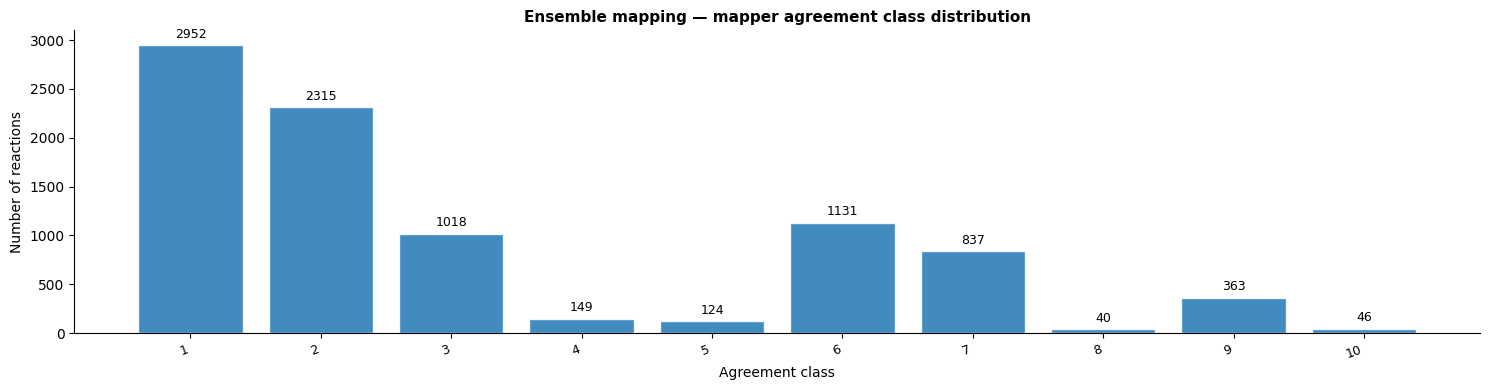

Total ensemble-validated reactions: 8975


In [7]:
import matplotlib.pyplot as plt

print(f"df_aam shape: {df_aam.shape}")
print(f"Columns: {list(df_aam.columns)}")

if "class" in df_aam.columns:
    _vc_class = df_aam["class"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(max(6, len(_vc_class) * 1.5), 4))
    bars = ax.bar(
        _vc_class.index.astype(str),
        _vc_class.values,
        color="#1F77B4",
        alpha=0.85,
        edgecolor="white",
    )
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_xlabel("Agreement class", fontsize=10)
    ax.set_ylabel("Number of reactions", fontsize=10)
    ax.set_title(
        "Ensemble mapping — mapper agreement class distribution",
        fontsize=11,
        fontweight="bold",
    )
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=20, ha="right", fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f"Total ensemble-validated reactions: {len(df_aam)}")
else:
    print("'class' column not found. Available columns:", list(df_aam.columns))
    display(df_aam.head(3))

**Q1 — Ensemble mapping**

Given a DataFrame with several mapper columns, `ensemble_maps(df, map_cols)`:
- canonicalizes each mapper column with `std_canon(...)`,
- accepts rows where all canonical values are identical,
- runs `refinement(...)` on the leftovers,
- returns `(solved_df, unsolved_df)` where `solved_df` keeps only metadata + one `aam` column.
- combine all high-confident maps and drop duplicate if possible


---

<details> <summary><b>Solution:</b></summary>

```python
from typing import List, Tuple
import pandas as pd
from tqdm.auto import tqdm

tqdm.pandas() 

def ensemble_maps(df: pd.DataFrame, map_cols: List[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    missing = [c for c in map_cols if c not in df.columns]
    if missing:
        raise KeyError(f"missing columns: {missing}")

    canon_cols = []
    for col in map_cols:
        tgt = f"{col}_canon"
        canon_cols.append(tgt)
        tqdm.pandas(desc=f"Canonicalization {col}") 
        df[tgt] = df[col].progress_apply(std_canon)

    match, unmatch = extract_aam(df, keys=tuple(canon_cols))
    solve, unsolve = refinement(unmatch, aam_cols=tuple(canon_cols))

    out = pd.concat([match, solve], axis=0).reset_index(drop=True)
    out = out.drop_duplicates(subset="aam", keep="first").reset_index(drop=True)
    return out, unsolve

    
```
</details>

## 3. Rule library construction

With high-confidence `aam` maps in hand, convert each mapped reaction into an ITS graph, extract the reaction center, and turn that center into a reusable rule entry for the library.

In [8]:
df_aam.drop_duplicates(subset='aam', inplace=True)

We now can use high level function from synkit to convert reaction with atom map to ITS graph and extract reaction center

Reaction center construction: 100%|██████████| 8962/8962 [00:26<00:00, 333.57it/s]


<Axes: >

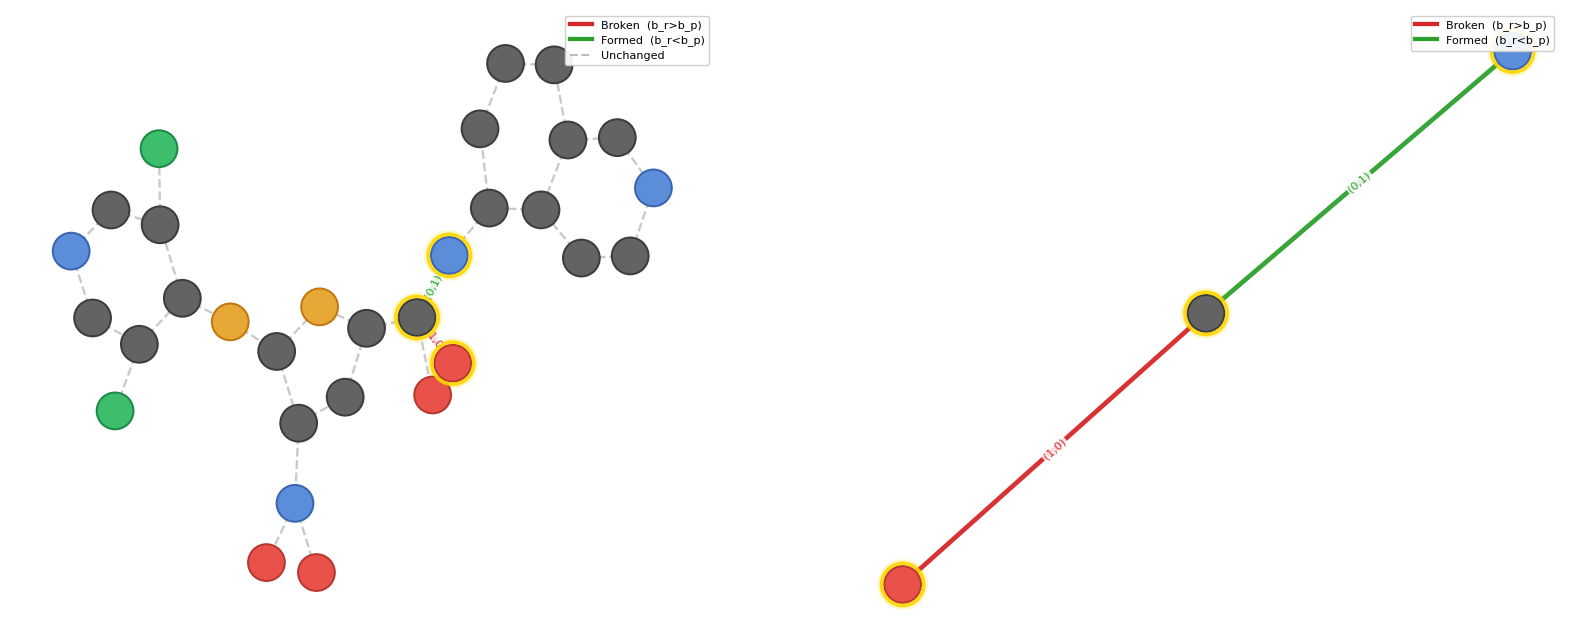

In [9]:
from synkit.IO import rsmi_to_its
import matplotlib.pyplot as plt
from synedu.Utils.its_vis import visualize_its


tqdm.pandas(desc="ITS construction")
df_aam['ITS'] = df_aam['aam'].progress_apply(rsmi_to_its, core=False)

tqdm.pandas(desc="Reaction center construction")
df_aam['RC'] = df_aam['aam'].progress_apply(rsmi_to_its, core=True)


fig, ax = plt.subplots(1, 2, figsize=(20, 8))

visualize_its(df_aam['ITS'][1], show_node_labels=False, ax=ax[0])
visualize_its(df_aam['RC'][1], show_node_labels=False, ax=ax[1])

Now we have 8,962 reaction centers, but some of them can be isomorphic, we can develop a simple pairwise grouping algorithm

With a set $S=\{\Gamma_1,\Gamma_2,\dots,\Gamma_n\},\qquad n\ge 2$, we want a partition $T$ of $S$ into isomorphism classes.

**Pseudocode**

$$
\begin{array}{l}
T \leftarrow \varnothing\\[4pt]
S \leftarrow \{\Gamma_1,\Gamma_2,\dots,\Gamma_n\}\\[6pt]
\text{while } S \neq \varnothing :\\
\quad q^{*} \leftarrow \text{arbitrary element of } S\\
\quad S \leftarrow S \setminus \{q^{*}\}\\
\quad C \leftarrow \{q^{*}\}\\
\quad \text{for each } q \in \mathrm{copy}(S) :\\
\quad\quad \text{if }\operatorname{VF2\_iso}(q,q^{*}) \text{ then}\\
\quad\quad\quad C \leftarrow C \cup \{q\}\\
\quad\quad\quad S \leftarrow S \setminus \{q\}\\
\quad\quad \text{end if}\\
\quad \text{end for}\\
\quad T \leftarrow T \cup \{C\}\\
\text{end while}\\[4pt]
\text{return } T
\end{array}
$$


In SynKit, this algorithm is implemented in `GraphCluster`

In [10]:
from synkit.Graph.Matcher.graph_cluster import GraphCluster

cls = GraphCluster(node_label_default=['element', 'charge'], edge_attribute='order')
result = cls.fit(df_aam.to_dict('records'), rule_key='RC', attribute_key=None)
result[0]

{'R-id': 0,
 'reactions': 'COC(=O)[C@H](CCCCNC(=O)OCc1ccccc1)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O.O>>COC(=O)[C@H](CCCCN)NC(=O)Nc1cc(OC)cc(C(C)(C)C)c1O.O=C(O)OCc1ccccc1',
 'rxn_mapper': '[CH3:1][O:2][C:3](=[O:4])[C@H:5]([CH2:6][CH2:7][CH2:8][CH2:9][NH:10][C:29](=[O:28])[O:31][CH2:32][c:33]1[cH:34][cH:35][cH:36][cH:37][cH:38]1)[NH:11][C:12](=[O:13])[NH:14][c:15]1[cH:16][c:17]([O:18][CH3:19])[cH:20][c:21]([C:22]([CH3:23])([CH3:24])[CH3:25])[c:26]1[OH:27].[OH2:30]>>[CH3:1][O:2][C:3](=[O:4])[C@H:5]([CH2:6][CH2:7][CH2:8][CH2:9][NH2:10])[NH:11][C:12](=[O:13])[NH:14][c:15]1[cH:16][c:17]([O:18][CH3:19])[cH:20][c:21]([C:22]([CH3:23])([CH3:24])[CH3:25])[c:26]1[OH:27].[O:28]=[C:29]([OH:30])[O:31][CH2:32][c:33]1[cH:34][cH:35][cH:36][cH:37][cH:38]1',
 'graphormer': '[CH3:33][C:32]([CH3:34])([CH3:35])[c:31]1[c:36]([OH:37])[c:25]([cH:26][c:27]([cH:30]1)[O:28][CH3:29])[NH:24][C:22](=[O:23])[NH:21][C@@H:5]([CH2:6][CH2:7][CH2:8][CH2:9][NH:10][C:11]([O:13][CH2:14][c:15]1[cH:16][cH:17][cH:18][cH:19][cH:20]1)=[O:

**Q2 — Unique rules**

You have a list of dictionaries where each item represents a reaction-center record and contains a `class` label (the isomorphism class). Implement `get_unique_rc(...)` to extract one representative reaction center per class.

---

<details> <summary><b>Solution:</b></summary>

```python
from typing import List, Dict, Any

def get_unique_rc(
    items: List[Dict[str, Any]],
    class_key: str = "class",
    rc_key: str = "RC",
    keep: str = "first",
) -> List[Any]:
    if keep not in ("first", "last"):
        raise ValueError("keep must be 'first' or 'last'")

    reps: dict = {}  # class -> (idx, rc)
    for i, it in enumerate(items):
        cls = it.get(class_key)
        if cls is None:
            continue
        rc = it.get(rc_key)
        if keep == "first":
            if cls not in reps:
                reps[cls] = (i, rc)
        else:  # keep == "last"
            reps[cls] = (i, rc)

    # sort by stored index and return rc values
    ordered = sorted(reps.values(), key=lambda x: x[0])
    return [rc for _, rc in ordered]


    
```
</details>

Alternatively, we can leverage Synkit’s utility functions

In [11]:
from synkit.Utils.utils import stratified_random_sample

rc = stratified_random_sample(result, 'class')
rc = [value['RC'] for value in rc]
print(len(rc))

212


### Rule library size vs dataset size

A key question: does the rule vocabulary *saturate* (good for generalization)
or grow indefinitely (poor coverage at test time)?
We subsample the dataset at increasing sizes and plot unique rule count.

In [12]:
import copy
from typing import Optional, Sequence, Tuple, Union
import networkx as nx

AttrSpec = Union[None, str, Sequence[str]]


def _ensure_defaults_nodes(G: nx.Graph, attr: str) -> None:
    for _, d in G.nodes(data=True):
        d.setdefault(attr, "")


def _ensure_defaults_edges(G: nx.Graph, attr: str) -> None:
    for _, _, d in G.edges(data=True):
        d.setdefault(attr, "")


def _combine_node_attrs(G: nx.Graph, attrs: Sequence[str], name: str) -> None:
    for _, d in G.nodes(data=True):
        d[name] = "|".join(str(d.get(a, "")) for a in attrs)


def _combine_edge_attrs(G: nx.Graph, attrs: Sequence[str], name: str) -> None:
    for _, _, d in G.edges(data=True):
        d[name] = "|".join(str(d.get(a, "")) for a in attrs)


def prepare_graph(
    graph: nx.Graph,
    node_attrs: AttrSpec = None,
    edge_attrs: AttrSpec = None,
) -> Tuple[nx.Graph, Optional[str], Optional[str]]:
    G = copy.deepcopy(graph)

    # nodes
    if isinstance(node_attrs, str):
        node_name = node_attrs
        _ensure_defaults_nodes(G, node_name)
    elif node_attrs:
        node_list = list(node_attrs)
        node_name = node_list[0] if len(node_list) == 1 else "_wl_node_combined"
        if len(node_list) == 1:
            _ensure_defaults_nodes(G, node_name)
        else:
            _combine_node_attrs(G, node_list, node_name)
    else:
        node_name = None

    # edges
    if isinstance(edge_attrs, str):
        edge_name = edge_attrs
        _ensure_defaults_edges(G, edge_name)
    elif edge_attrs:
        edge_list = list(edge_attrs)
        edge_name = edge_list[0] if len(edge_list) == 1 else "_wl_edge_combined"
        if len(edge_list) == 1:
            _ensure_defaults_edges(G, edge_name)
        else:
            _combine_edge_attrs(G, edge_list, edge_name)
    else:
        edge_name = None

    return G, node_name, edge_name


def wl_hash(
    graph: nx.Graph,
    node_attrs: AttrSpec = ['element', 'charge'],
    edge_attrs: AttrSpec = ['order'],
    iterations: int = 2,
    digest_size: int = 16,
) -> str:
    G, n_attr, e_attr = prepare_graph(graph, node_attrs, edge_attrs)
    return nx.weisfeiler_lehman_graph_hash(
        G,
        node_attr=n_attr,
        edge_attr=e_attr,
        iterations=iterations,
        digest_size=digest_size,
    )

In [13]:
tqdm.pandas(desc="WL hash calculation")
df_aam['wl_hash'] = df_aam['RC'].progress_map(wl_hash)
df_aam['wl_hash_its'] = df_aam['ITS'].progress_map(wl_hash)

WL hash calculation: 100%|██████████| 8962/8962 [00:05<00:00, 1721.46it/s]


In [14]:
df_aam['wl_hash'].value_counts()

wl_hash
189caaebfb6a16175c8fdce574df4dc7    1529
633abb9b0a2395fb794cd79888c84fe0    1203
de1d893c9f39698e858f4fbbc0756da4     543
b0c5c47ca6e9e0086edf4c234fde9005     541
8e97d91df532d0affdfd5e65a9d0e7ef     493
                                    ... 
ac3fc1dbdeab56f7690b9e5339fc2e40       1
dffb63720c753dd3d58755ea9ad47b24       1
fd7a96c56e7660258bbd0c27f7203a32       1
53d30ef2eec77b99e4abfa43a8e65648       1
17ea37e16268d4455e30b48bab049689       1
Name: count, Length: 212, dtype: int64

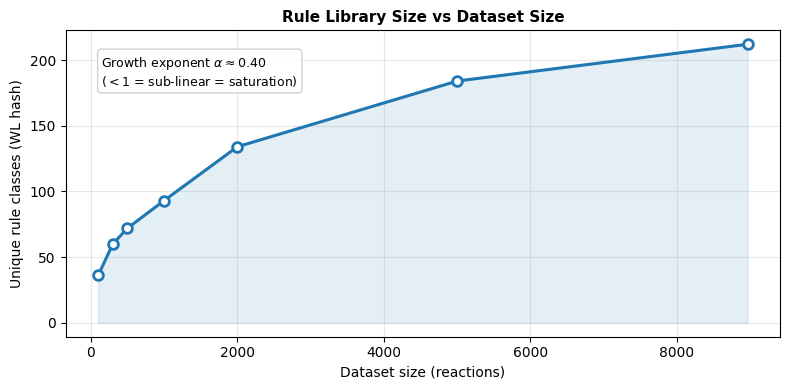

At full dataset (8962 rxns): 212 unique rules


In [15]:
import matplotlib.pyplot as plt
import numpy as np

_sizes = [100, 300, 500, 1000, 2000, 5000, len(df_aam)]
_sizes = [s for s in _sizes if s <= len(df_aam)]
_unique_rules = []

for sz in _sizes:
    _sub = df_aam.sample(n=sz, random_state=42) if sz < len(df_aam) else df_aam
    _unique_rules.append(_sub['wl_hash'].nunique())

fig, ax = plt.subplots(figsize=(8, 4), facecolor='white')
ax.plot(
    _sizes,
    _unique_rules,
    'o-',
    color='#1F77B4',
    linewidth=2.2,
    markersize=7,
    markerfacecolor='white',
    markeredgewidth=2,
)
ax.fill_between(_sizes, _unique_rules, alpha=0.12, color='#1F77B4')

# Fit power law for annotation
_xs = np.log(np.array(_sizes, dtype=float))
_ys = np.log(np.array(_unique_rules, dtype=float))
_coef = np.polyfit(_xs, _ys, 1)
ax.text(
    0.05,
    0.92,
    f'Growth exponent $\\alpha \\approx {_coef[0]:.2f}$\n'
    f'($<$1 = sub-linear = saturation)',
    transform=ax.transAxes,
    fontsize=9,
    va='top',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ccc', alpha=0.9),
)

ax.set_xlabel('Dataset size (reactions)', fontsize=10)
ax.set_ylabel('Unique rule classes (WL hash)', fontsize=10)
ax.set_title('Rule Library Size vs Dataset Size', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'At full dataset ({_sizes[-1]} rxns): {_unique_rules[-1]} unique rules')

Applying the same reduction logic to isomorphic ITS graphs is feasible, though computationally more expensive than focusing solely on the reaction center.
To optimize the computationally intensive ITS reduction, we can leverage Weisfeiler-Lehman [[6]](#ref-6) pre-filtering (per **S06**). This ensures that expensive isomorphism checks are only performed on high-probability candidates

### Rule frequency and cluster size distribution

The WL hash partitions reactions by their reaction-centre topology. The **left panel** shows the distribution of cluster sizes on a log scale — a long tail is typical (a few very common rules, many rare ones). The **right panel** shows the 20 most frequent rules. Singleton clusters represent unique reaction patterns seen only once in the dataset.

### Top-10 rule classes — reaction center gallery

The most frequent WL hash classes represent the most common reaction mechanisms in the dataset.  
We visualize the reaction center ITS graph for the representative of each top-10 class.


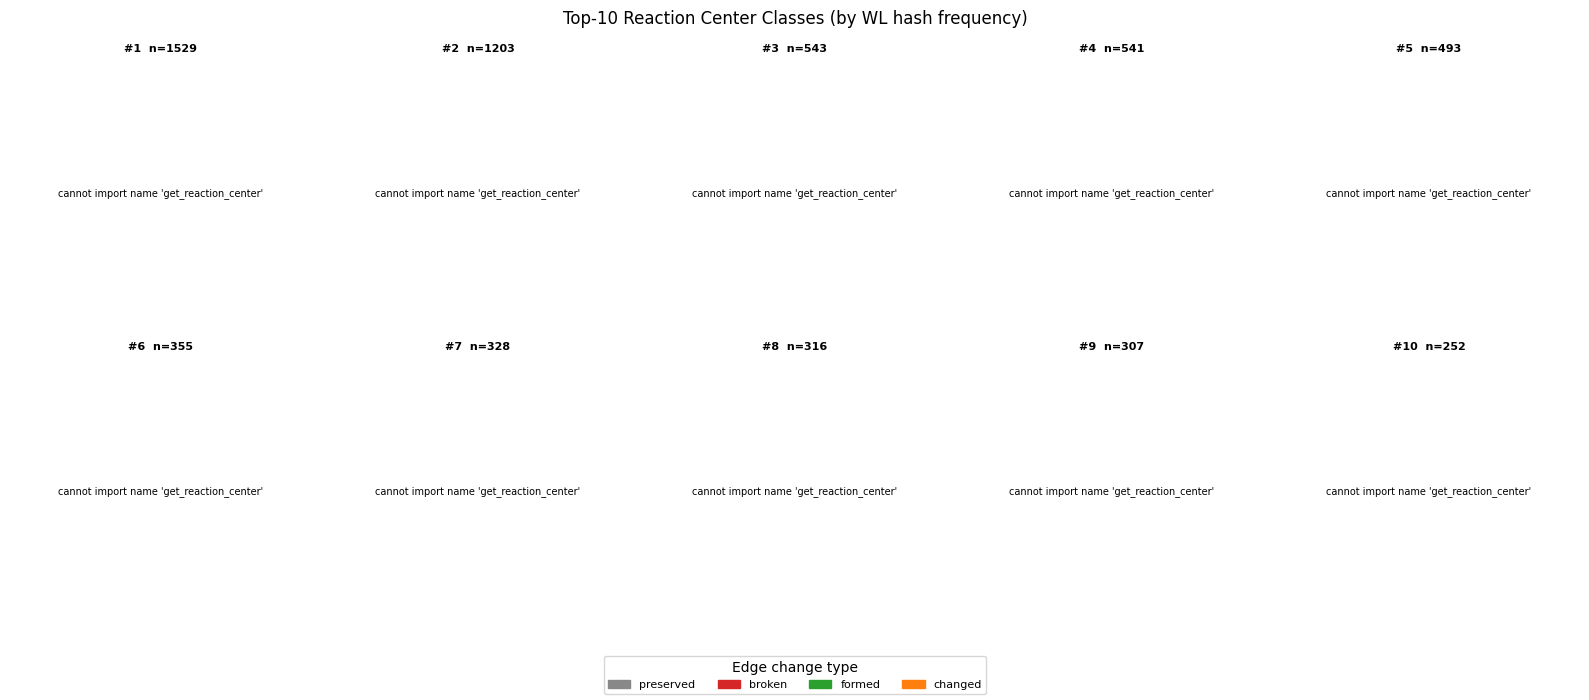

In [16]:
import matplotlib.pyplot as plt
import networkx as nx

# ── build top-10 frequency table ────────────────────────────────────────
_freq = df_aam['wl_hash'].value_counts()
_top10 = _freq.head(10)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

_EDGE_COLOR = {
    'preserved': '#888888',
    'broken': '#D62728',
    'formed': '#2CA02C',
    'changed': '#FF7F0E',
}

for rank, (wl_hash, count) in enumerate(_top10.items()):
    ax = axes[rank]
    # pick the first reaction with this hash
    row = df_aam[df_aam['wl_hash'] == wl_hash].iloc[0]
    try:
        from synkit.IO import rsmi_to_its
        from synkit.Graph import get_reaction_center

        _its = rsmi_to_its(row['aam'])
        _rc = get_reaction_center(_its)
        pos = nx.spring_layout(_rc, seed=rank)
        ec = []
        for u, v, d in _rc.edges(data=True):
            br, bp = d.get('order', (0.0, 0.0))
            br, bp = float(br), float(bp)
            if br > 0 and bp > 0 and abs(br - bp) < 1e-6:
                ec.append(_EDGE_COLOR['preserved'])
            elif br > 0 and bp < 1e-6:
                ec.append(_EDGE_COLOR['broken'])
            elif br < 1e-6 and bp > 0:
                ec.append(_EDGE_COLOR['formed'])
            else:
                ec.append(_EDGE_COLOR['changed'])
        nlabels = {n: d.get('element', '?') for n, d in _rc.nodes(data=True)}
        nx.draw_networkx(
            _rc,
            pos=pos,
            ax=ax,
            node_color='#AEC6E8',
            node_size=400,
            labels=nlabels,
            font_size=7,
            edge_color=ec,
            width=2.2,
            arrows=False,
        )
    except Exception as exc:
        ax.text(
            0.5,
            0.5,
            str(exc)[:40],
            ha='center',
            va='center',
            transform=ax.transAxes,
            fontsize=7,
        )
    ax.set_title(f"#{rank+1}  n={count}", fontsize=8, fontweight='bold')
    ax.axis('off')

from matplotlib.patches import Patch

legend = [Patch(color=c, label=k) for k, c in _EDGE_COLOR.items()]
fig.legend(
    handles=legend, loc='lower center', ncol=4, fontsize=8, title='Edge change type'
)
fig.suptitle('Top-10 Reaction Center Classes (by WL hash frequency)', fontsize=12)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

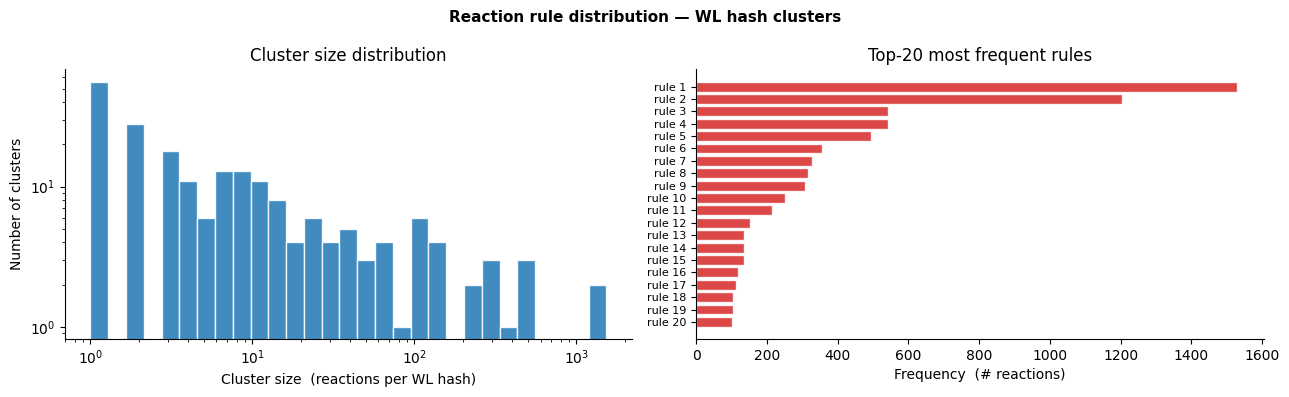

Unique rules (WL hashes):  212
Most frequent rule:        1529 reactions
Singleton rules:           56  (26.4%)


In [17]:
import matplotlib.pyplot as plt
import numpy as np

_vc = df_aam['wl_hash'].value_counts()
_sizes = _vc.values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    "Reaction rule distribution — WL hash clusters", fontsize=11, fontweight="bold"
)

# Left: log-log histogram of cluster sizes
_max = max(_sizes)
_bins = np.logspace(0, np.log10(_max + 1), min(30, _max + 2))
axes[0].hist(_sizes, bins=_bins, color="#1F77B4", alpha=0.85, edgecolor="white")
axes[0].set_xscale("log")
if _sizes.max() > 5:
    axes[0].set_yscale("log")
axes[0].set_xlabel("Cluster size  (reactions per WL hash)")
axes[0].set_ylabel("Number of clusters")
axes[0].set_title("Cluster size distribution")
axes[0].spines[["top", "right"]].set_visible(False)

# Right: top-20 most frequent rules
_top = _vc.head(20)
axes[1].barh(
    range(len(_top)), _top.values[::-1], color="#D62728", alpha=0.85, edgecolor="white"
)
axes[1].set_yticks(range(len(_top)))
axes[1].set_yticklabels([f"rule {i+1}" for i in range(len(_top))][::-1], fontsize=8)
axes[1].set_xlabel("Frequency  (# reactions)")
axes[1].set_title("Top-20 most frequent rules")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Unique rules (WL hashes):  {len(_vc)}")
print(f"Most frequent rule:        {_sizes.max()} reactions")
print(
    f"Singleton rules:           {(_sizes == 1).sum()}  ({(_sizes==1).sum()/len(_vc)*100:.1f}%)"
)

While `wl_hash` effectively yields the same equivalence classes as graph isomorphism in this instance, it is important to note that the WL hash is an approximation. For absolute precision, it should be supplemented or replaced by a formal isomorphism check.

**Q3 — ITS uniqueness**

Now integrate a function anme `cluster_with_wl_prefilter(df, graph_key, wl_key)` to prefilter the bucket before

---

<details> <summary><b>Solution:</b></summary>

```python
import pandas as pd
from synkit.Graph.Matcher.graph_cluster import GraphCluster

def cluster_with_wl_prefilter(
    df: pd.DataFrame,
    graph_key: str = "ITS",
    wl_key: str = "wl_hash_its",
) -> pd.DataFrame:
    df2 = df.copy()
    if wl_key not in df2.columns:
        raise KeyError(f"{wl_key} not found in DataFrame")

    results = []
    next_class = 0
    for wl_val, idxs in df2.groupby(wl_key).groups.items():
        records = df2.loc[idxs].to_dict("records")
        cls = GraphCluster(node_label_default=["element", "charge"], edge_attribute="order")
        out = cls.fit(records, rule_key=graph_key, attribute_key=None)
        recs = out[0] if isinstance(out, tuple) else out
        bucket_df = pd.DataFrame(recs)
        if bucket_df.empty:
            continue

        if "class" in bucket_df.columns:
            bucket_df["class"] = bucket_df["class"].astype(int) + next_class
            next_class = int(bucket_df["class"].max()) + 1
        else:
            n = len(bucket_df)
            bucket_df = bucket_df.reset_index(drop=True)
            bucket_df["class"] = range(next_class, next_class + n)
            next_class += n

        results.append(bucket_df)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()
        
```
</details>

Now, we should convert reaction center to DPO rules

In [18]:
from synkit.IO import its_to_gml

rules = [its_to_gml(value) for value in rc]

Example GML snippet (one rule, L/K/R encoded as sub-blocks):

```gml
rule [
  ruleID "rule"
  left [
    edge [ source 1 target 3 label "-" ]
    edge [ source 2 target 4 label "-" ]
  ]
  context [
    node [ id 1 label "C" ]
    node [ id 2 label "C" ]
    node [ id 3 label "B" ]
    node [ id 4 label "Br" ]
  ]
  right [
    edge [ source 1 target 2 label "-" ]
    edge [ source 3 target 4 label "-" ]
  ]
]
```

Interpretation

- ruleID — rule identifier.

- context (K) — nodes/edges preserved (no structural change). Usually contains node entries; treat it as the graph backbone.

- left (L) — edges/nodes that are deleted or changed when applying the rule.

- right (R) — edges/nodes that are added or changed (the new connections).


This GML rule is usable by MØD [[7]](#ref-7), but there’s a mismatch: MØD requires explicit hydrogens, while our pipeline produces rules with implicit hydrogens.

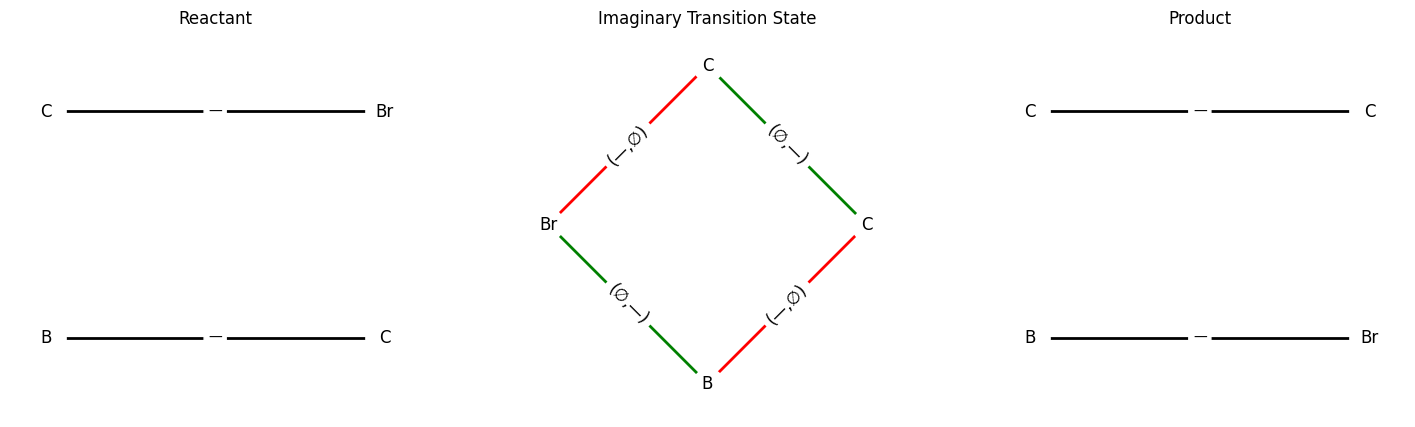

In [19]:
from synkit.Vis.rule_vis import RuleVis

vis = RuleVis()
vis.vis(rules[4])

**Q4 — Data pipeline**

Implement a single high-level function that ingests a pandas DataFrame containing multiple atom-mapping candidates per reaction and produces a deduplicated library of reaction centers / DPO rules (optionally exported to GML), plus the rows that remain ambiguous.

---

<details> <summary><b>Solution:</b></summary>

```python


from typing import List
from synkit.IO import rsmi_to_its, its_to_gml
from synkit.Graph.Matcher.graph_cluster import GraphCluster
from synkit.Utils.utils import stratified_random_sample

def rule_lib_pipeline(
        data: pd.DataFrame, 
        map_cols: List[str], 
        export_gml: bool = False):
    
    # 1. get high confiden aam
    data, _ = ensemble_maps(data, map_cols)

    # 2. convert to ITS/RC
    tqdm.pandas(desc="ITS construction") 
    data['ITS'] = data['aam'].progress_apply(rsmi_to_its, core=False) 

    tqdm.pandas(desc="Reaction center construction") 
    data['RC'] = data['aam'].progress_apply(rsmi_to_its, core=True) 

    # 3. compute wl_hash for prefilter
    tqdm.pandas(desc="WL hash calculation") 
    data['wl_hash'] = data['RC'].progress_map(wl_hash)

    # 4. clustering
    cls = GraphCluster(node_label_default=['element', 'charge'], edge_attribute='order')
    result = cls.fit(data.to_dict('records'), rule_key='RC', attribute_key='wl_hash') # GraphCluster can prefilter directly

    # 5. get unique reaction center
    rc_records = stratified_random_sample(result, 'class')
    rc = [
        value['RC']
        for value in tqdm(rc_records, desc="Extracting unique RCs")
    ]

    # 6. convert to gml
    if export_gml:
        gml = [
        its_to_gml(i)
        for i in tqdm(rc, desc="Exporting GML")
    ]
        return gml
    
    return rc
    
    
        
```
</details>

## 4. Quiz

- What challenges arise when expanding to explicit hydrogens for MØD applications?
- How is a transformation rule structured to accommodate incomplete reactions?
- By what mechanism can a rule be modified to encapsulate chemical context, such as specific functional groups?


## 5. Discussion

- Atom-mapping quality can be significantly improved through ensemble techniques, specifically by performing isomorphism checks on generated ITS graphs.
- While WL-based canonicalization is effective for pre-filtering and deduplication, it remains an approximation and cannot fully replace exact isomorphism checks for definitive verification.
- Clustering reaction centers in large-scale datasets is computationally intensive; however, implementing a WL hashing pre-filter significantly accelerates the process by pruning the search space.
- Rules can be persisted as NetworkX graph objects for deep computational tasks or exported in GML format for a lightweight, human-readable, and explainable representation.

## 6. References

1. <a id="ref-9"></a> Phan, T.-L.; González Laffitte, M. E.; Weinbauer, K.; Merkle, D.; Andersen, J. L.; Fagerberg, R.; Gatter, T.; Stadler, P. F.  
   *SynKit: A Graph-Based Python Framework for Rule-Based Reaction Modeling and Analysis.*  
   **Journal of Chemical Information and Modeling** (2025).   
   https://doi.org/10.5281/zenodo.16925060

2. <a id="ref-2"></a> Schwaller, P. *et al.*  
   *Extraction of organic chemistry grammar from unsupervised learning of chemical reactions (RXNMapper).*  
   **Science Advances** (2021).  
   https://doi.org/10.1126/sciadv.abe4166

3. <a id="ref-4"></a> Nugmanov, R.; Dyubankova, N.; Gedich, A.; Wegner, J. K.  
   *Bidirectional graphormer for reactivity understanding: neural network trained to reaction atom-to-atom mapping task.*  
   **Journal of Chemical Information and Modeling** **62**(14), 3307–3315 (2022).  
   https://doi.org/10.1021/acs.jcim.2c00344

4. <a id="ref-4"></a> Chen, S.; An, S.; Babazade, R.; Jung, Y.  
   *Precise atom-to-atom mapping for organic reactions via human-in-the-loop machine learning.*  
   **Nature Communications** **15**(1), 2250 (2024).

5. <a id="ref-5"></a> Phan, T.-L.; Weinbauer, K.; González Laffitte, M. E.; Pan, Y.; Merkle, D.; Andersen, J. L.; Fagerberg, R.; Flamm, C.; Stadler, P. F.  
   *SynTemp: Efficient Extraction of Graph-Based Reaction Rules from Large-Scale Reaction Databases.*  
   **Journal of Chemical Information and Modeling** (2025).  
   https://doi.org/10.1021/acs.jcim.4c01795

7. <a id="ref-7"></a> Shervashidze, N.; Schweitzer, P.; van Leeuwen, E. J.; Mehlhorn, K.; Borgwardt, K. M.  
   *Weisfeiler–Lehman graph kernels.*  
   **Journal of Machine Learning Research** **12**(9) (2011).   
   https://www.jmlr.org/papers/volume12/shervashidze11a/shervashidze11a.pdf

8. <a id="ref-8"></a> Andersen, J. L.; Flamm, C.; Merkle, D.; Stadler, P. F.  
   *A software package for chemically inspired graph transformation.*  
   In **International Conference on Graph Transformation**, 73–88 (Springer, 2016).   
   https://doi.org/10.1007/978-3-319-40530-8_5
